# Phase I – Baseline Credit Default Model (Taiwan Dataset)

In this notebook, we build a first proof‑of‑concept model for predicting default on the Taiwan credit‑card dataset from the UCI repository. The goals for Phase I are:

- Load and inspect the dataset (structure, feature types, default rate).
- Train a conventional logistic regression baseline using scikit‑learn.
- Report basic performance metrics (AUC, accuracy, precision/recall, F1).

This scikit‑learn logistic model serves as an initial frequentist benchmark. In later phases, we will:

- Implement a manual logistic regression model in Python (NumPy, gradient descent) as our primary frequentist method.
- Implement a Bayesian logistic regression model in R as our supervised Bayesian method.
- Compare these models with an emphasis on reliability of predicted default probabilities and uncertainty quantification.


### Load and explore Taiwan dataset

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Load Taiwan UCI credit card default dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1, index_col=0)  # Skip first row, use first column as index

In [19]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

# Target variable: default payment next month (1 = default, 0 = no default)
print("\nDefault rate:")
print(df['default payment next month'].value_counts(normalize=True).round(4))

# Numeric summary for key columns
print("\nSummary stats (numeric columns):")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())

# Correlation with target (top 10)
corr_with_target = df[numeric_cols].corr()['default payment next month'].abs().sort_values(ascending=False)
print("\nTop 10 correlations with default (absolute):")
print(corr_with_target.head(10))


Dataset shape: (30000, 24)

Data types:
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

First 5 rows:
    LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  

## Train–test split and feature scaling

We split the data into stratified training and test sets so that the default rate is similar in both samples, and we standardize the features for the logistic regression baseline. This setup will also be reused later for the manual and Bayesian models to ensure fair comparisons.

In [21]:
from sklearn.model_selection import train_test_split

# Renamed for convenience
df_ = df.rename(columns={'default payment next month': 'default'})

X = df_.drop(columns=['default'])
y = df_['default']

# Stratified split to preserve default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class proportions similar in train and test -> important for imbalanced dataset
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train default rate:", y_train.mean().round(4))
print("Test default rate:", y_test.mean().round(4))


Train shape: (24000, 23)
Test shape: (6000, 23)
Train default rate: 0.2212
Test default rate: 0.2212


In [23]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

# Fit only on training data, then apply to both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print("Train feature means (approx):", np.mean(X_train_scaled, axis=0)[:5].round(3))
print("Train feature stds  (approx):", np.std(X_train_scaled, axis=0)[:5].round(3))


Scaled train shape: (24000, 23)
Scaled test shape: (6000, 23)
Train feature means (approx): [ 0.  0. -0.  0. -0.]
Train feature stds  (approx): [1. 1. 1. 1. 1.]


## Baseline frequentist logistic regression (scikit‑learn)

As a first non‑Bayesian model for Phase I, we fit a standard logistic regression classifier using scikit‑learn. This reflects the conventional approach used in many credit‑scoring applications:

- Linear log‑odds in the features.
- Probability of default as the output.
- Coefficients that can (in principle) be interpreted economically.

This model is not our final “method 1”; instead, it serves as:

- A quick frequentist baseline to understand what performance levels are reasonable on this dataset.
- A reference point for validating our later manual logistic implementation.


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_clf = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight=None  # simple baseline: no class weighting yet. Will perform imbalance handling in later phases
)

log_clf.fit(X_train_scaled, y_train)

y_pred = log_clf.predict(X_test_scaled)
y_proba = log_clf.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f"Test AUC: {auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

Test AUC: 0.7076

Classification report:
              precision    recall  f1-score   support

           0     0.8178    0.9692    0.8871      4673
           1     0.6883    0.2396    0.3555      1327

    accuracy                         0.8078      6000
   macro avg     0.7531    0.6044    0.6213      6000
weighted avg     0.7892    0.8078    0.7695      6000



### Baseline performance summary

The baseline logistic model achieves an AUC of about 0.71 and roughly 81% accuracy, but its default‑class recall is only about 24%, meaning that it misses most of the borrowers who do default. This is acceptable as a starting point, but it highlights the need to look beyond raw accuracy and to investigate calibration and uncertainty for predicted default probabilities.


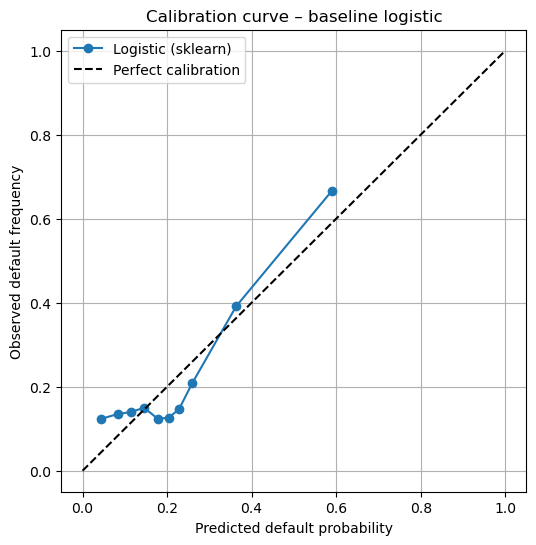

In [25]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Logistic (sklearn)')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Predicted default probability')
plt.ylabel('Observed default frequency')
plt.title('Calibration curve – baseline logistic')
plt.legend()
plt.grid(True)
plt.show()

### Baseline Plot Summary
The calibration curve shows that the baseline logistic model’s predicted probabilities track observed default rates reasonably well. At low and high predicted PDs, the model tends to slightly underestimate the true default frequency, but the mid‑range (around 30–40% PD) is close to perfectly calibrated. This suggests that, despite its moderate AUC, the logistic baseline produces probabilities that are not severely miscalibrated on average—providing a meaningful reference point for the manual and Bayesian models we will build next.

## Next steps (future phases)

In later phases of the project, we will:

- Implement a manual logistic regression model in Python to better understand the optimization and link function.
- Fit a Bayesian logistic regression model in R to obtain posterior distributions and credible intervals for probabilities of default.
- For all models (manual frequentist, Bayesian, and this scikit‑learn baseline), compute:

  - Calibration curves / reliability diagrams
  - Brier scores
  - Posterior‑based uncertainty summaries (for the Bayesian model)

The main research question is not only “which model has the highest AUC,” but how trustworthy and well‑calibrated their predicted default probabilities are, and whether Bayesian inference provides a more honest treatment of uncertainty than conventional logistic regression in this credit‑risk setting.
